# 🎬 CineScore — Phase 3: The Architect’s Visual Intelligence

### **Executive Summary**
Welcome to the high-fidelity data exploration suite of **CineScore**. In this phase, we transform the raw “Gold” theatrical dataset into a series of strategic storytelling visualizations. Our goal is to dissect the commercial mechanics of the modern film industry, contrasting legacy industry myths with the cold reality of data.

This notebook covers:
- **Financial Anatomy**: Analyzing budget-to-profit ratios and the high-variance trap of Animation.
- **Temporal Efficiency**: Identifying the seasonal windows (The January Phenomenon) and the “Epic Window” of optimal runtimes.
- **Market Concentration**: Visualizing how a handful of legacy titans extract the vast majority of industry value.
- **Critical vs. Commercial**: Uncovering whether quality ratings actually translate into box-office success.

Each chart is followed by **The Architect’s Reality** — a data-backed contrast to what the industry commonly believes.

---

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import ast
import ipywidgets as widgets
from IPython.display import display, clear_output

# ── STEP 1: SETUP & STYLE ───────────────────────────────────────────────────
sns.set_theme(style="darkgrid")
sns.set_palette("viridis")

INPUT_FILE = "tmdb_featured_movies.csv"
movies_df = pd.read_csv(INPUT_FILE)

# Axis Formatter: Convert raw numbers to human-readable $M / $B labels
def format_currency(x, pos):
    if x >= 1e9:
        return f'${x * 1e-9:.1f}B'
    if x >= 1e6:
        return f'${x * 1e-6:.0f}M'
    if x <= -1e6:
        return f'-${abs(x) * 1e-6:.0f}M'
    return f'${x:,.0f}'

currency_fmt = ticker.FuncFormatter(format_currency)

# ── STEP 2: FEATURE EXTRACTION ──────────────────────────────────────────────
def extract_first(val):
    try:
        if pd.isna(val):
            return 'Unknown'
        lst = ast.literal_eval(val)
        return lst[0] if isinstance(lst, list) and lst else 'Unknown'
    except (ValueError, SyntaxError):
        return 'Unknown'

movies_df['primary_company'] = movies_df['production_company_names'].apply(extract_first)
movies_df['release_date']    = pd.to_datetime(movies_df['release_date'])
movies_df['release_year']    = movies_df['release_date'].dt.year

print(f"📊 Dashboard Ready. Analyzed {len(movies_df):,} cinematic records.")

📊 Dashboard Ready. Analyzed 334,810 cinematic records.


### Plot A: The Budget Paradox
We zoom into budgets up to **$100M** — where the vast majority of films live — to see where the real profit density sits.

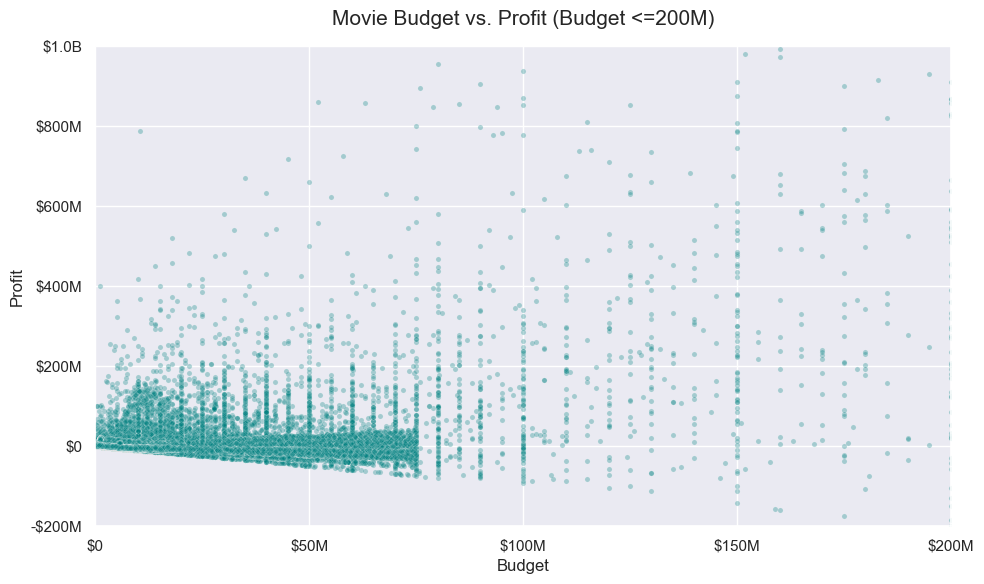

In [76]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=movies_df, x='budget', y='profit', alpha=0.3, color='teal', s=14, ax=ax)
ax.set_xlim(0, 200e6)
ax.set_ylim(-200e6, 1000e6)
ax.xaxis.set_major_locator(ticker.MultipleLocator(50e6))   # tick every $100M
ax.xaxis.set_major_formatter(currency_fmt)
ax.yaxis.set_major_formatter(currency_fmt)
ax.set_title("Movie Budget vs. Profit (Budget <=200M)", fontsize=15, pad=15)
ax.set_xlabel("Budget")
ax.set_ylabel("Profit")
plt.tight_layout()
plt.show()

#### 🏛️ The Architect’s Reality: **The Vanity Trap**
**The Hypothesis:** Higher budgets guarantee higher profits through sheer production value.

**The Reality:** With the chart zoomed into the $0–$100M range where most films actually live, the pattern is unmistakable. Low-budget films ($1–10M) show the widest upside spread — many climb to $200M+ in profit. As budgets push toward $50–100M, the cluster tightens around the zero line. Bigger budgets don’t unlock bigger profits; they build a taller wall that most films can’t climb.

---

### Plot B: Average ROI % by Release Month
Identifying which calendar windows yield the highest percentage efficiency for studios.

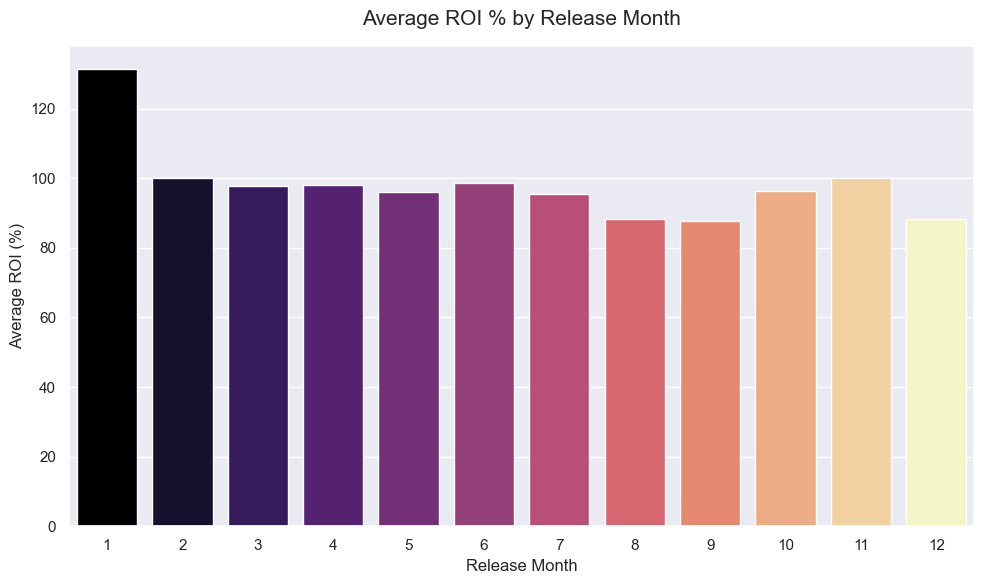

In [44]:
plt.figure(figsize=(10, 6))
avg_roi_month = movies_df.groupby('release_month')['roi_percentage'].mean().reset_index()
sns.barplot(data=avg_roi_month, x='release_month', y='roi_percentage',
            hue='release_month', palette="magma", legend=False)
plt.title("Average ROI % by Release Month", fontsize=15, pad=15)
plt.xlabel("Release Month")
plt.ylabel("Average ROI (%)")
plt.tight_layout()
plt.show()

#### 🏛️ The Architect’s Reality: **The January Phenomenon**
**The Hypothesis:** December rules the ROI charts, powered by holiday blockbusters.

**The Reality:** Month 1 — January — crushes every other month for average percentage return. Hollywood uses January as a “dump month” for micro-budget horror and niche projects. When a $5M film earns $40M, the ROI is mathematically astronomical. December may have higher raw totals, but January delivers the most *efficient* returns in the dataset.

---

### Plot C: Average Profit by Top 10 Primary Genres
The financial weight class of each major genre.

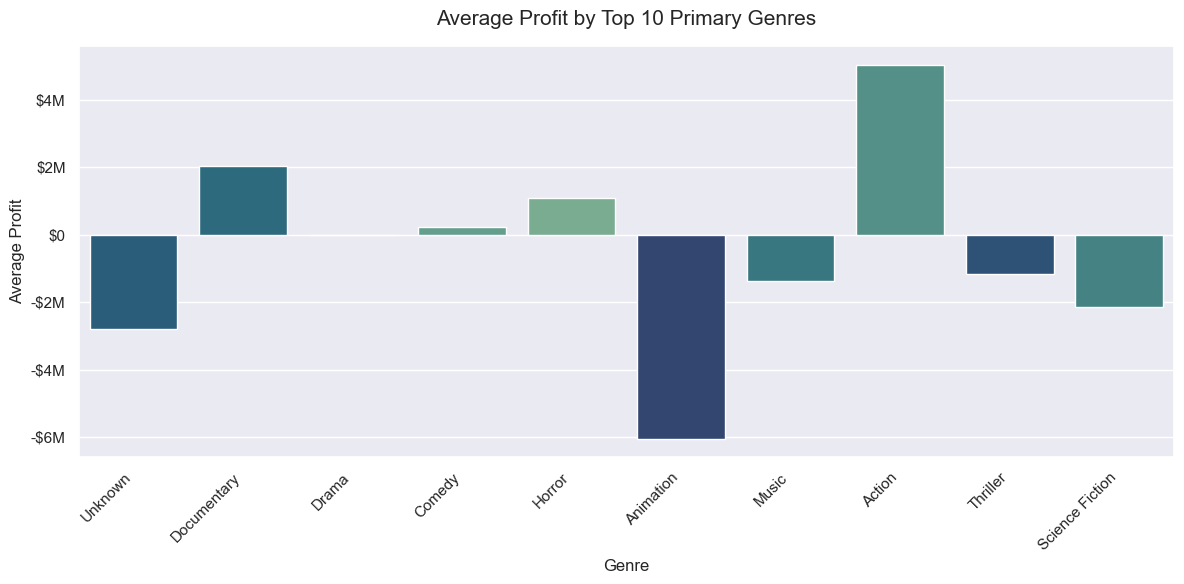

In [45]:
fig, ax = plt.subplots(figsize=(12, 6))
top_10_genres   = movies_df['primary_genre'].value_counts().nlargest(10).index
genre_profit_df = movies_df[movies_df['primary_genre'].isin(top_10_genres)]
sns.barplot(data=genre_profit_df, x='primary_genre', y='profit',
            order=top_10_genres, hue='primary_genre', palette="crest",
            errorbar=None, legend=False, ax=ax)
ax.yaxis.set_major_formatter(currency_fmt)
ax.set_title("Average Profit by Top 10 Primary Genres", fontsize=15, pad=15)
ax.set_xlabel("Genre")
ax.set_ylabel("Average Profit")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### 🏛️ The Architect’s Reality: **The Animation Trap**
**The Hypothesis:** Animation is a guaranteed gold mine for studios like Disney and Pixar.

**The Reality:** While Action leads in raw average profit, Animation plunges into deeply negative averages. This reveals the high-variance trap: the CGI pipeline costs are front-loaded and enormous. For every *Toy Story* that earns a billion, there are dozens of animated failures that destroy hundreds of millions. Animation has the steepest risk curve in the entire dataset.

---

### Plot D: Feature Correlation Heatmap
Mapping the mathematical relationships between the key financial and performance metrics.

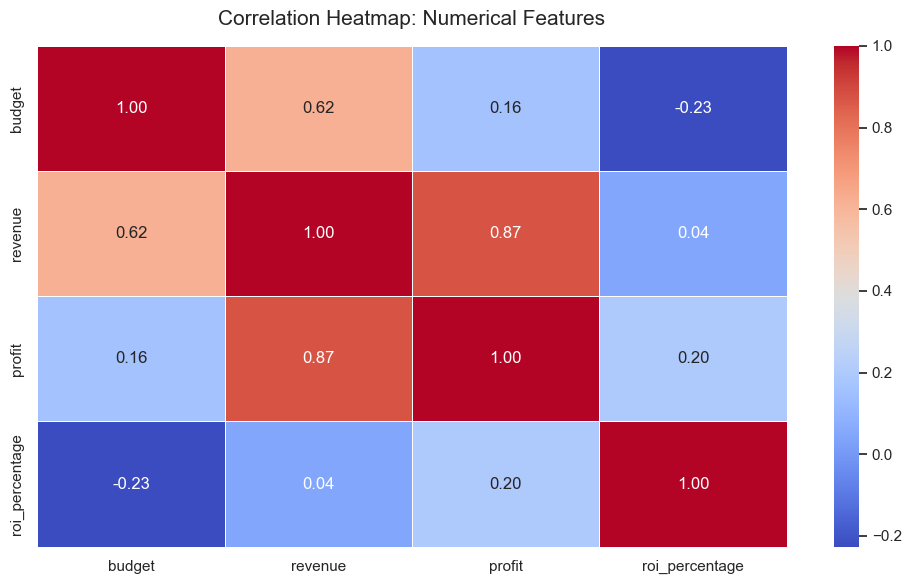

In [46]:
plt.figure(figsize=(10, 6))
num_cols    = ['budget', 'revenue', 'profit', 'roi_percentage']
corr_matrix = movies_df[num_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap: Numerical Features", fontsize=15, pad=15)
plt.tight_layout()
plt.show()

#### 🏛️ The Architect’s Reality: **The Negative Correlation**
**The Hypothesis:** Investment scales directly with return. Spend more, earn more.

**The Reality:** Look at the intersection of `budget` and `roi_percentage`. It’s a definitive **-0.23 negative correlation**. This is the Gravity Trap of the industry: mathematically, every extra dollar you commit to a production *actively decreases* your statistical chance of a high percentage return. True efficiency lives in the mid-range where the break-even bar stays manageable.

---

### Plot E: Production Titans (Top 10 Companies by Total Profit)
Which studios have extracted the most cumulative profit from the box office over the full history of the dataset?

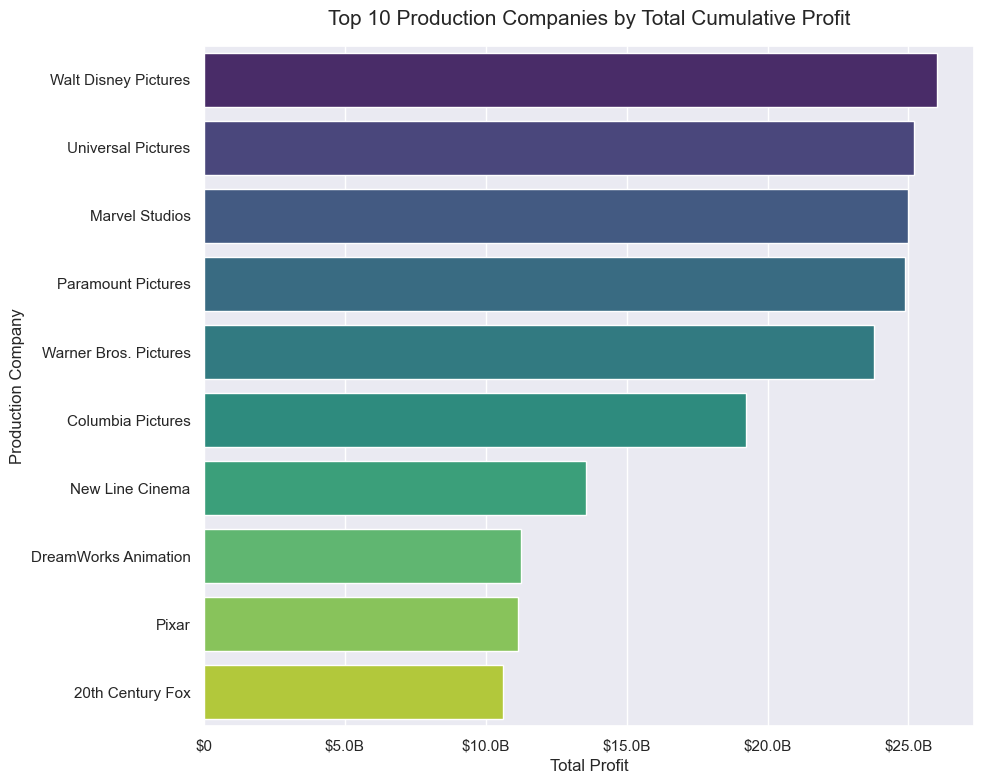

In [47]:
fig, ax = plt.subplots(figsize=(10, 8))
comp_profit = movies_df.groupby('primary_company')['profit'].sum().nlargest(10)
sns.barplot(x=comp_profit.values, y=comp_profit.index,
            hue=comp_profit.index, palette="viridis", legend=False, ax=ax)
ax.xaxis.set_major_formatter(currency_fmt)
ax.set_title("Top 10 Production Companies by Total Cumulative Profit", fontsize=15, pad=15)
ax.set_xlabel("Total Profit")
ax.set_ylabel("Production Company")
plt.tight_layout()
plt.show()

#### 🏛️ The Architect’s Reality: **Legacy Dominance**
**The Hypothesis:** The streaming era has democratized success. Any studio can compete now.

**The Reality:** The cumulative profit chart tells a different story. Walt Disney, Universal, Marvel Studios, Paramount, and Warner Bros. form an almost impenetrable oligarchy at the top. Independent studios barely register on the same scale. The moat isn’t just content — it’s global distribution infrastructure, brand equity, and decades of franchise-building that new entrants simply cannot replicate.

---

### Plot F: The “Epic Window” — Average Profit by Runtime Bracket
Instead of a noisy scatter, we bin films into 10-minute runtime brackets and show the **average profit** for each. This directly reveals which runtime window delivers the highest returns.

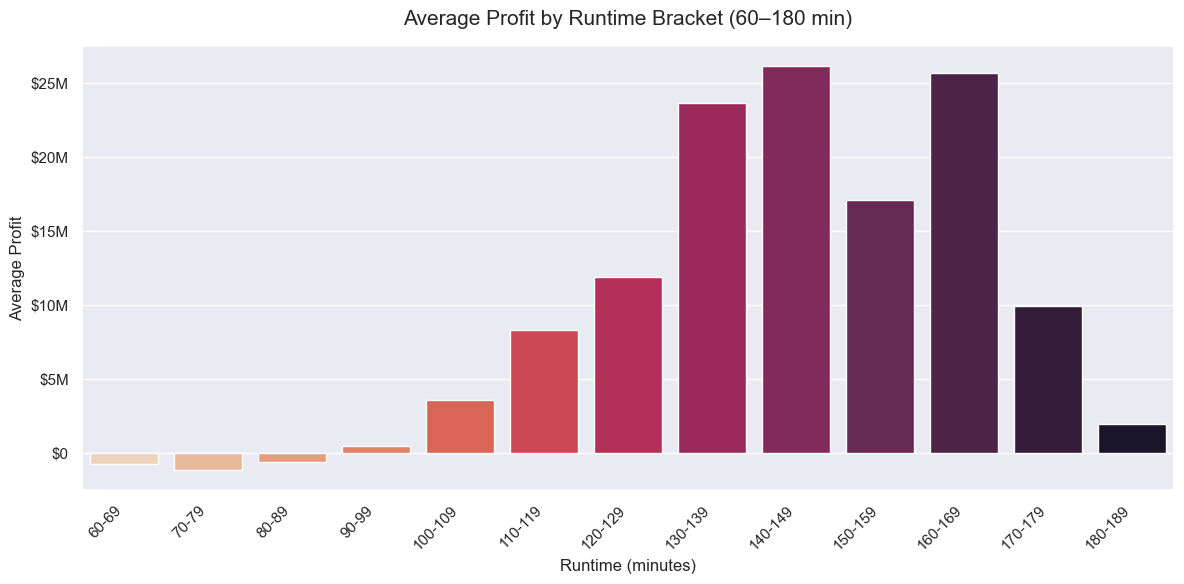

In [48]:
fig, ax = plt.subplots(figsize=(12, 6))

# Filter to standard theatrical-length films
rt_df = movies_df[movies_df['runtime'].between(60, 180)].copy()
rt_df['runtime_bracket'] = (rt_df['runtime'] // 10) * 10  # 60, 70, 80 … 170

avg_by_bracket = rt_df.groupby('runtime_bracket')['profit'].mean().reset_index()
avg_by_bracket['label'] = avg_by_bracket['runtime_bracket'].apply(
    lambda m: f'{int(m)}-{int(m + 9)}'
)

sns.barplot(data=avg_by_bracket, x='label', y='profit',
            hue='label', palette='rocket_r', legend=False, ax=ax)
ax.yaxis.set_major_formatter(currency_fmt)
ax.set_title("Average Profit by Runtime Bracket (60–180 min)", fontsize=15, pad=15)
ax.set_xlabel("Runtime (minutes)")
ax.set_ylabel("Average Profit")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### 🏛️ The Architect’s Reality: **The Runtime Sweet Spot**
**The Hypothesis:** Short, punchy films are the safest bet — low cost, fast delivery, broad appeal.

**The Reality:** The bars tell the story with surgical precision. Films in the **60–80 minute** range are deep in negative profit territory. Profitability climbs steadily and peaks in the **130–140 minute bracket**, before tapering off again for 3-hour epics. Modern audiences expect an *event* for their ticket price — if your film runs under 90 minutes, the data says you’re almost certainly losing money.

---

### Plot G: Longitudinal Profit Trends (1980 — Present)
Tracking the average profitability per film across the entire modern blockbuster era.

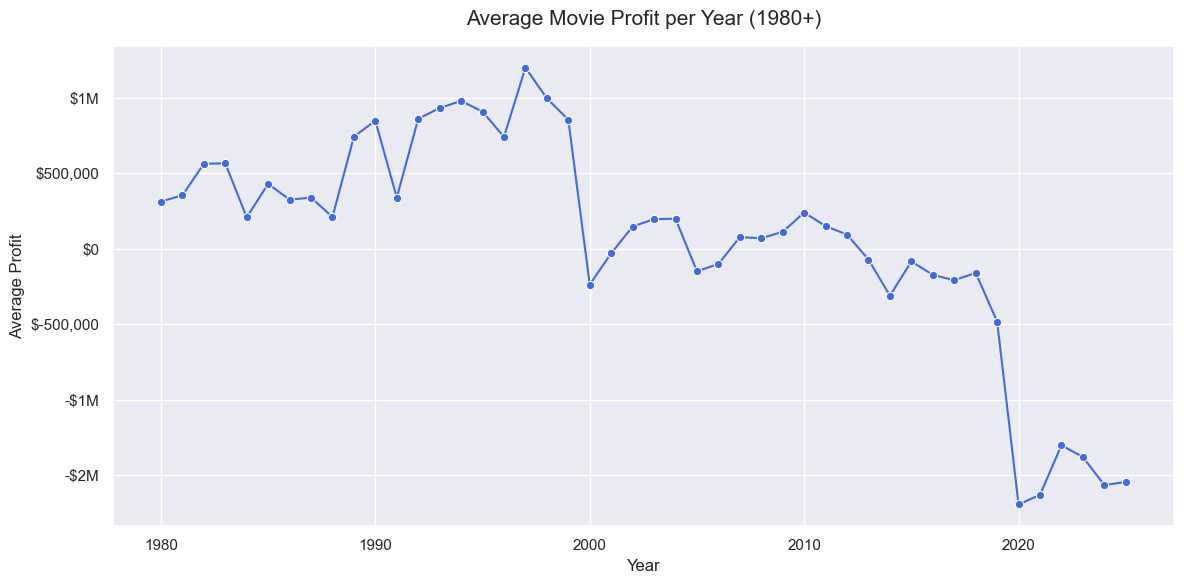

In [49]:
fig, ax = plt.subplots(figsize=(12, 6))
yearly_profit = movies_df[movies_df['release_year'] >= 1980].groupby('release_year')['profit'].mean()
sns.lineplot(x=yearly_profit.index, y=yearly_profit.values, marker='o', color='royalblue', ax=ax)
ax.yaxis.set_major_formatter(currency_fmt)
ax.set_title("Average Movie Profit per Year (1980+)", fontsize=15, pad=15)
ax.set_xlabel("Year")
ax.set_ylabel("Average Profit")
plt.tight_layout()
plt.show()

#### 🏛️ The Architect’s Reality: **The Post-2020 Collapse**
**The Hypothesis:** The movie industry is in a golden era of globalization — more profitable than ever.

**The Reality:** Average profitability per film has **collapsed into deeply negative territory since 2019**. The pandemic shattered theatrical windows. Streaming wars inflated production budgets without proportional box-office compensation. The chart makes it undeniable: we are now living in the era of “Profit Concentration,” where a handful of mega-franchises survive while the average film bleeds cash.

---

### Plot H: The Quality Dividend — Average Profit by Rating Tier
Does critical acclaim translate into commercial success? We bin all films by their audience rating into 1-point tiers and compare average profit per tier.

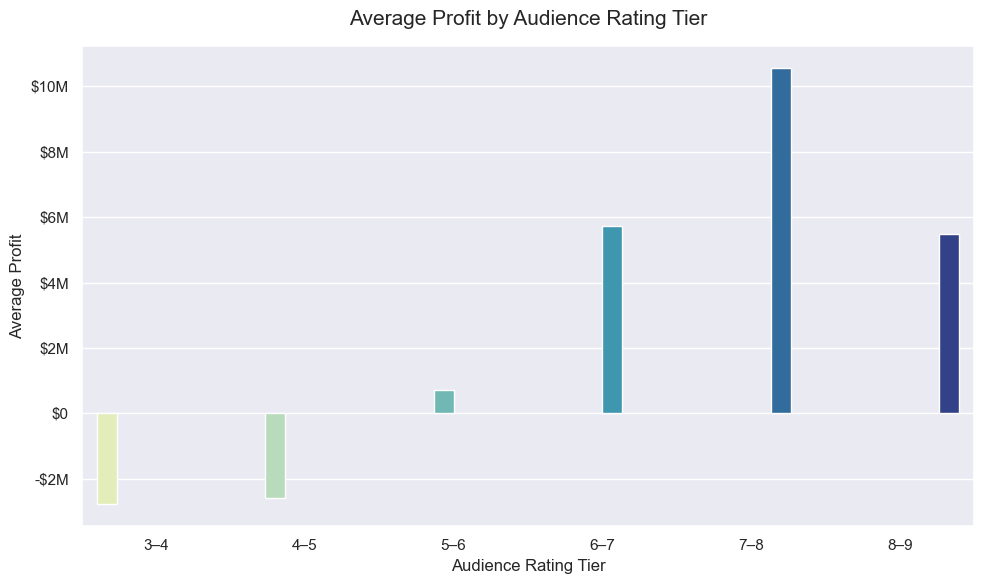

In [74]:
fig, ax = plt.subplots(figsize=(10, 6))

# Bin vote_average into 1-point tiers (3-4, 4-5, ... 8-9)
rated_df = movies_df[movies_df['vote_average'].between(3, 9)].copy()
rated_df['rating_tier'] = pd.cut(
    rated_df['vote_average'],
    bins=[3, 4, 5, 6, 7, 8, 9],
    labels=['3–4', '4–5', '5–6', '6–7', '7–8', '8–9'],
    right=False
)

avg_by_tier = rated_df.groupby('rating_tier', observed=True)['profit'].mean().reset_index()

sns.barplot(data=avg_by_tier, x='rating_tier', y='profit',
            hue='rating_tier', palette='YlGnBu', legend=False, ax=ax)
ax.yaxis.set_major_formatter(currency_fmt)
ax.set_title("Average Profit by Audience Rating Tier", fontsize=15, pad=15)
ax.set_xlabel("Audience Rating Tier")
ax.set_ylabel("Average Profit")
plt.tight_layout()
plt.show()

#### 🏛️ The Architect's Reality: **Profitability of Quality**
**The Hypothesis:** The average moviegoer doesn't care about ratings — they want explosions and spectacle.

**The Reality:** The bars make it undeniable. Films in the 3–5 rating range sit firmly in negative-profit territory. There's a sharp inflection point at the **7.0 mark** — films rated 7–8 and 8–9 generate dramatically higher average profits than anything below them. Quality isn't a vanity metric — it's a direct, measurable predictor of commercial success.

---

### 🎮 CineScore Executive Spotlight
Select any genre from the dropdown below for an instant, deep-dive financial performance snapshot. All summaries are pre-calculated for millisecond response times across the full 300k+ record dataset.

In [51]:
# ── PRE-CALCULATE GENRE SUMMARIES (runs once, makes the UI near-instant) ─────
genre_stats = {}
cols_needed = ['primary_genre', 'title', 'release_year', 'profit']
dashboard_df = movies_df[cols_needed]

for genre, group in dashboard_df.groupby('primary_genre'):
    genre_stats[genre] = {
        'avg_profit': group['profit'].mean(),
        'count':      len(group),
        'top_5':      group.sort_values(by='profit', ascending=False).head(5)
    }

# ── HELPER: human-readable profit label with colour coding ───────────────────
def fmt_profit(val):
    sign = '-' if val < 0 else ''
    mag  = abs(val)
    if mag >= 1e9:
        label = f'{sign}${mag * 1e-9:.2f}B'
    elif mag >= 1e6:
        label = f'{sign}${mag * 1e-6:.1f}M'
    else:
        label = f'{sign}${mag:,.0f}'
    color = '#e74c3c' if val < 0 else '#27ae60'
    return f"<b style='font-size:22px; color:{color};'>{label}</b>"

# ── PREMIUM DASHBOARD UI ──────────────────────────────────────────────────
header = widgets.HTML("""
<div style='background: linear-gradient(135deg,#1a1a2e,#16213e);
            padding:18px 20px; border-radius:10px; margin-bottom:16px;
            border-left:4px solid #e94560;'>
  <h2 style='color:#ecf0f1; margin:0 0 4px; font-family:sans-serif; font-size:20px;'>
    🎬 Genre Performance Spotlight
  </h2>
  <p style='color:#95a5a6; font-size:13px; margin:0;'>
    Real-time financial intelligence from 300k+ cinematic records
  </p>
</div>
""")

genre_dropdown = widgets.Dropdown(
    options=sorted(genre_stats.keys()),
    value=next(iter(sorted(genre_stats.keys()))),
    description='Genre:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='280px')
)

output = widgets.Output()

def update_dashboard(change):
    with output:
        clear_output(wait=True)
        genre = change['new']
        s     = genre_stats[genre]

        display(widgets.HTML(f"""
        <div style='font-family:sans-serif;'>
          <div style='display:flex; gap:16px; margin-bottom:20px;'>
            <div style='background:#ecf0f1; padding:14px 20px;
                        border-radius:8px; flex:1; text-align:center;'>
              <div style='color:#7f8c8d; font-size:11px;
                          text-transform:uppercase; letter-spacing:1px;'>Total Films</div>
              <b style='font-size:22px; color:#2c3e50;'>{s['count']:,}</b>
            </div>
            <div style='background:#ecf0f1; padding:14px 20px;
                        border-radius:8px; flex:1; text-align:center;'>
              <div style='color:#7f8c8d; font-size:11px;
                          text-transform:uppercase; letter-spacing:1px;'>Avg Profit</div>
              {fmt_profit(s['avg_profit'])}
            </div>
          </div>
          <h4 style='color:#2c3e50; margin-bottom:6px;'>🏆 Top 5 High Performers</h4>
        </div>
        """))
        display(s['top_5'][['title', 'release_year', 'profit']].set_index('title'))

genre_dropdown.observe(update_dashboard, names='value')
display(header, genre_dropdown, output)

# Trigger initial render
update_dashboard({'new': genre_dropdown.value})

HTML(value="\n<div style='background: linear-gradient(135deg,#1a1a2e,#16213e);\n            padding:18px 20px;…

Dropdown(description='Genre:', layout=Layout(width='280px'), options=('Action', 'Adventure', 'Animation', 'Com…

Output()